In [19]:
%%time

##################################
#Imports

from datetime import datetime
import s3fs
import xarray as xr
import pyinterp
from widetrax import DataPreprocessing as dp
from widetrax import Spectra as sp
import numpy as np
import json
from watermark import watermark
import time
import platform
from shapely.geometry import shape, box

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
#from widetrax import Spectra as sp
import plot_psd1X as pp2X

CPU times: user 49 μs, sys: 1 μs, total: 50 μs
Wall time: 52 μs


In [20]:
# CONFIG
reg="AG"
season="JAS"

# NOT MODIFY

if reg=="GS":
    roi = {
        "lon_min": -60,
        "lon_max": -50,
        "lat_min": 30,
        "lat_max": 40
    }
    pos_reg=[-85, -30, 15, 55]
elif reg=="AG":
    roi = {
        "lon_min": 20,
        "lon_max": 40,
        "lat_min": -40,
        "lat_max": -20
    }
    pos_reg=[0, 60, -55, -25]

with open("mostly_ocean_boxes_filtered.geojson") as f:
    data = json.load(f)

roi_poly = box(roi["lon_min"], roi["lat_min"],
               roi["lon_max"], roi["lat_max"])

selected = []

for feature in data["features"]:
    poly = shape(feature["geometry"])
    if poly.intersects(roi_poly):
        selected.append(poly)

/Users/contrema/Documents/Postdoc/SWOTv2/plot_psd1X.py:66: RuntimeWarning: divide by zero encountered in divide
  mask = (1 / freqs) >= (2 * max_horizontal_gridsize[i])
/Users/contrema/Documents/Postdoc/SWOTv2/plot_psd1X.py:100: RuntimeWarning: divide by zero encountered in divide
  ax2 = ax.secondary_xaxis("bottom", functions=(lambda x: 1 / x, lambda x: 1 / x))
/Users/contrema/Documents/Postdoc/SWOTv2/plot_psd1X.py:100: RuntimeWarning: divide by zero encountered in divide
  ax2 = ax.secondary_xaxis("bottom", functions=(lambda x: 1 / x, lambda x: 1 / x))
/Users/contrema/Documents/Postdoc/SWOTv2/plot_psd1X.py:66: RuntimeWarning: divide by zero encountered in divide
  mask = (1 / freqs) >= (2 * max_horizontal_gridsize[i])
/Users/contrema/Documents/Postdoc/SWOTv2/plot_psd1X.py:100: RuntimeWarning: divide by zero encountered in divide
  ax2 = ax.secondary_xaxis("bottom", functions=(lambda x: 1 / x, lambda x: 1 / x))
/Users/contrema/Documents/Postdoc/SWOTv2/plot_psd1X.py:100: RuntimeWarning

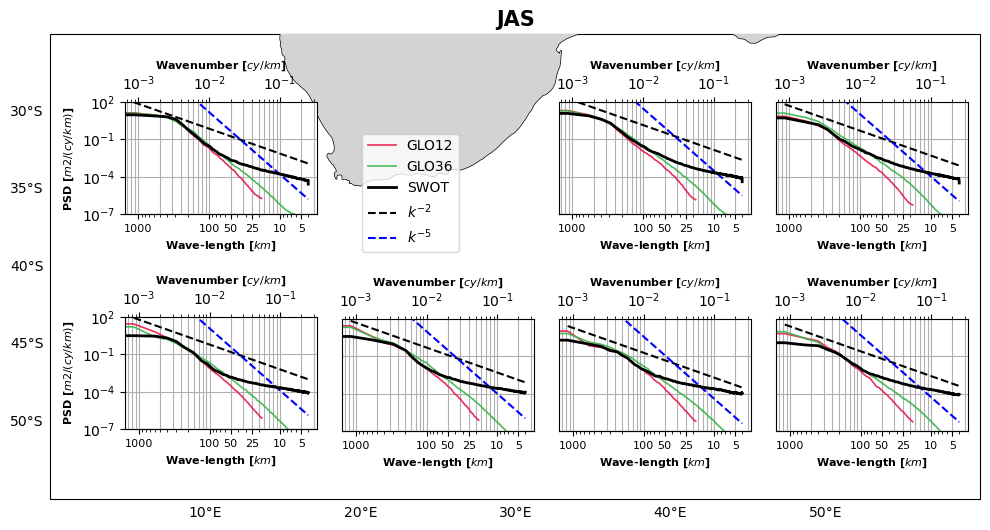

In [21]:



#import importlib
#importlib.reload(pp2X)
# Colors plot
colors = [
    "#E6194B",  # red
    "#3CB44B",  # green
    "k",
    #"#FFE119",  # yellow
    #"#4363D8",  # blue
    #"#F58231",  # orange
    #"#911EB4",  # purple
]

#MODEL LOAD
models=["GLO12","GLO36","SWOT"]

max_horizontal_gridsize = [9,3,0] #,2.224,2.224,25,7,0]

fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent(pos_reg, crs=ccrs.PlateCarree())
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=2,
    color='gray',
    alpha=0.5,
    linestyle='--'
)

# Optional: clean up label placement
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}
gl.xlines = False
gl.ylines = False
ax.set_title(season,fontsize=15, fontweight="bold", color="black")
ax.add_feature(cfeature.LAND,zorder=10, facecolor="lightgray")
ax.add_feature(cfeature.COASTLINE)
#for poly in selected:
#    ax.add_geometries([poly], ccrs.PlateCarree(),
#                      edgecolor="black", facecolor="none")

box=0
for i, poly in enumerate(selected):



    # Size of inset (tune this)

    if (reg=="AG"): 
        # Box center
        lon_min, lat_min, lon_max, lat_max = poly.bounds
        lon_c = 0.7 * (lon_min + lon_max)
        lat_c = 0.7 * (lat_min + lat_max)

        # Convert lon/lat → figure coordinates
        x_fig, y_fig = ax.transData.transform(
         ccrs.PlateCarree().transform_point(lon_c-10, lat_c+16, ccrs.PlateCarree())
        )
        x_fig, y_fig = fig.transFigure.inverted().transform((x_fig, y_fig))
        w, h = 0.16, 0.14
        if box==0:
            inset_ax = fig.add_axes([x_fig - w/2, y_fig - h/6, w, h])
        else:
            inset_ax = fig.add_axes([x_fig - w/2, y_fig - h/2, w, h])
    elif (reg=="GS"): 
        lon_min, lat_min, lon_max, lat_max = poly.bounds
        lon_c = 0.6 * (lon_min + lon_max)
        lat_c = 0.6 * (lat_min + lat_max)

        # Convert lon/lat → figure coordinates
        x_fig, y_fig = ax.transData.transform(
            ccrs.PlateCarree().transform_point(lon_c+15, lat_c-5, ccrs.PlateCarree())
        )
        x_fig, y_fig = fig.transFigure.inverted().transform((x_fig, y_fig))
        w, h = 0.14, 0.12
        inset_ax = fig.add_axes([x_fig - w/2, y_fig - h/2, w, h])

    spectrum=[]
    freq=[]
    # Plot spectrum
    for imod in ["GLORYS12","GLORYS36","SWOT"]:
        filename = reg + "_box_" + str(box) + "_" + season + "_" + imod + ".json"
        with open(filename, "r") as f:
            data = json.load(f)
        spectrum.append(data["Spectra"])
        freq.append(data["Frequency"])
        
    if box==0:
        pp2X.plot_psd(inset_ax, np.array(freq[0]).T, psds = spectrum, unit = "m2",psd_labels=models,legend=True,
                     loc_leg='upper left',bba_leg=(1.2,2.7), xlabel_upper=True,xlabel_lower=True, ylabel=True,
                     colors=colors,max_horizontal_gridsize=max_horizontal_gridsize,
                     savefig=True,filename=(reg +"_" + season + ".png"),plot_transparent=False)
    else:
        if reg=="AG":
            if (box!=4): # & (box!=6):
                pp2X.plot_psd(inset_ax, np.array(freq[0]).T, psds = spectrum, unit = "m2",psd_labels=models,legend=False,
                    xlabel_upper=True,xlabel_lower=True, ylabel=False, colors=colors,max_horizontal_gridsize=max_horizontal_gridsize,
                    savefig=True,filename=(reg +"_" + season + ".png"),plot_transparent=False)
                inset_ax.tick_params(axis='y', labelleft=False, length=0)
            else:
                pp2X.plot_psd(inset_ax, np.array(freq[0]).T,  psds = spectrum, unit = "m2",psd_labels=models,legend=False,
                    xlabel_upper=True,xlabel_lower=True, ylabel=True,colors=colors,max_horizontal_gridsize=max_horizontal_gridsize,
                    savefig=True, filename=(reg +"_" + season + ".png"),plot_transparent=False)
        elif reg=="GS": # & (box!=6):
            if (box!=3) & (box!=6):
                pp2X.plot_psd(inset_ax, np.array(freq[0]).T, psds = spectrum, unit = "m2",psd_labels=models,legend=False,
                    xlabel_upper=True,xlabel_lower=True, ylabel=False, colors=colors,max_horizontal_gridsize=max_horizontal_gridsize,
                    savefig=True,filename=(reg +"_" + season + ".png"),plot_transparent=False)
                inset_ax.tick_params(axis='y', labelleft=False, length=0)
            else:
                pp2X.plot_psd(inset_ax, np.array(freq[0]).T,  psds = spectrum, unit = "m2",psd_labels=models,legend=False,
                    xlabel_upper=True,xlabel_lower=True, ylabel=True,colors=colors,max_horizontal_gridsize=max_horizontal_gridsize,
                    savefig=True, filename=(reg +"_" + season + ".png"),plot_transparent=False)
    box=box+1

In [13]:
np.shape(spectrum)


(2, 297)

In [135]:
freqs=np.array(freq_GLORYS[0]).T
spectra=np.array(spectra_GLORYS).T
non_zero_freqs = freqs[freqs != 0]
np.shape(non_zero_freqs)
k_2 = non_zero_freqs ** -2 * (spectra[0][0]/ (non_zero_freqs[0] ** -2))